# Detecting LLM-Generated Student Essays with Transformer Fine-Tuning and Robustness Analysis

## TF-IDF Baseline: Feature-Based Classification & Data Ablations

**Team:** Joseph Souaiby & Huzaifah Wasima

**Dataset:** [Kaggle LLM Detect AI Generated Text](https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset) (~28k labeled essays)

## Data Preprocessing

In [1]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
DATA_PATH = "data/Training_Essay_Data.csv"
SEED = 42
MIN_CHARS = 50
LABEL_NAMES = {0: "Human", 1: "AI"}

In [3]:
def normText(text):
    text= re.sub(r"\s+", " ", text)
    return text.strip()


def balanceClasses(df, class_weight, total_samples=10000, lab_col_name='label'):
  temps=[]
  for label, weight in class_weight.items():
    samps=int(weight*total_samples)
    temp=df[df[lab_col_name] == label].sample(samps, random_state=SEED)
    temps.append(temp)
  balance_df = pd.concat(temps).reset_index(drop=True)
  return balance_df

def cleanData(df=None, path= DATA_PATH, text_col_name="text",label_col_name="generated") -> pd.DataFrame:
    if path != None:
      df =pd.read_csv(path)
    else:
      df=df
    df= df.rename(columns={text_col_name: "text", label_col_name: "label"})
    df["label"]= df["label"].astype(int)
    df["label_name"]=df["label"].map(LABEL_NAMES)
    df["text"]= df["text"].map(normText)
    df= df[df["text"].str.len() >= MIN_CHARS].copy()

    n_prev= len(df)

    df= df.drop_duplicates(subset="text").reset_index(drop=True)
    n_new= len(df)


    if n_prev!= n_new:
        print(f"Removed {n_prev - n_new} duplicate essays.")
    print(f"Dataset size after cleaning: {len(df):,} essays")
    print(f"Label distribution:\n{df['label'].value_counts().to_string()}\n")
    print(f"Data Sample: {df.head(5)}")
    return df

def splitData(df,val_size,test_size):
    train_val, test = train_test_split(df,test_size=test_size,stratify=df["label"],random_state=SEED)
    adj_val= val_size/(1.0 - test_size)
    train,val= train_test_split(train_val,test_size=adj_val,stratify=train_val["label"],random_state=SEED)
    print(f"Split sizes — train: {len(train):,}  val: {len(val):,}  test: {len(test):,}")
    return train, val, test

def getSplits(path= DATA_PATH,val_size= 0.1,test_size= 0.1):
    df = cleanData(path)
    train,val,test=splitData(df, val_size=val_size,test_size=test_size)

    X_train=train["text"].tolist()
    y_train=train["label"].tolist()

    X_val=val["text"].tolist()
    y_val=val["label"].tolist()

    X_test=test["text"].tolist()
    y_test=test["label"].tolist()
    return X_train, X_val, X_test, y_train, y_val, y_test

## Exploratory Data Analysis

### Class Distribution
Label balance between student-written (0) and AI-generated (1) essays.

### Text Length Analysis
Word count and character count distributions by class, including summary statistics and visual comparisons.

### Vocabulary & Stylistic Metrics
Type-token ratio, average word length, and average sentence length broken down by class.

### Top Frequent Terms
Most common unigrams and bigrams per class (stopwords removed) to identify potential prompt leakage or formatting artifacts.

### Punctuation & Structural Patterns
Comparison of punctuation frequency, paragraph counts, and formatting differences between human and AI-generated essays.



In [4]:
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

SEED = 42
np.random.seed(SEED)


sns.set_theme(style="whitegrid", palette="muted")

####Helper Functions

In [5]:
def save(fig, name, dir="results/eda_kaggle"):
    dir = Path(dir)
    dir.mkdir(parents=True, exist_ok=True)
    path = dir / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

def wordCount(text):
    return len(text.split())

def charCount(text):
    return len(text)

def avgWordLength(text):
    words = text.split()
    if words:
      return np.mean([len(w) for w in words])
    return 0.0

def avgSentenceLength(text):
    sentences = re.split(r"[.!?]+", text)
    res=[]
    for s in sentences:
      if s.strip():
        res.append(s.strip())
    if not sentences:
        return 0.0
    return np.mean([len(s.split()) for s in sentences])


def typeTokenRatio(text):
    tokens = text.lower().split()
    if tokens:
      return len(set(tokens))/len(tokens)
    return 0.0

def paragraphCount(text):
    res=[]
    for p in text.split("\n"):
      if p.strip():
        res.append(p)
    return max(1, len(res))

def punctuationFreq(text):
    n_punct=0
    for c in text:
      if c in string.punctuation:
        n_punct+=1
    return (n_punct / len(text) * 100) if text else 0.0

def topUgrams(texts, n= 1, top_k= 20):
    stop =ENGLISH_STOP_WORDS
    cntr: Counter = Counter()
    for text in texts:
      toks= re.findall(r"\b[a-z]+\b", text.lower())
      tokens=[]
      for t in toks:
        if t not in stop and len(t)>2:
          tokens.append(t)
      cntr.update(tokens)
    return cntr.most_common(top_k)

def topBgrams(texts, top_k=20):
  stop=ENGLISH_STOP_WORDS
  cntr: Counter = Counter()
  for text in texts:
    toks= re.findall(r"\b[a-z]+\b", text.lower())
    tokens=[]
    for t in toks:
      if t not in stop and len(t)>2:
        tokens.append(t)
    cntr.update(zip(tokens, tokens[1:]))
  return cntr.most_common(top_k)


def makeHistogram(data, save_path, f_name, bins=60, x_label=None, y_label="Count", suptitle=None, show=True):
    groups = list(data)
    num_plots = len(groups)
    fig, axes = plt.subplots(1, num_plots, figsize=(5.5 * num_plots, 4))

    if num_plots == 1:
        axes = [axes]

    for i, (name, grp) in enumerate(groups):
        axes[i].hist(grp, bins=bins)
        axes[i].set_title(name)
        axes[i].set_ylabel(y_label)
        if x_label:
            axes[i].set_xlabel(x_label)
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    if show:
      plt.show()
    save(fig, f_name, save_path)

def makeBoxPlot(df, data, col_name, suptitle, save_path, f_name, show=True):
  num_cols=len(data)
  fig, axes= plt.subplots(1, num_cols, figsize=(5*num_cols, 4))
  if num_cols == 1:
        axes = [axes]
  for ax,(label, (col, _)) in zip(axes, data.items()):
      sns.boxplot(data=df,x=col_name,y=col,hue=col_name,legend=False,ax=ax, showfliers=False)
      ax.set_title(label)
      ax.set_xlabel("")
  fig.suptitle(suptitle)
  plt.tight_layout()
  if show:
    plt.show()
  save(fig,f_name,  save_path)

def runAnalysis(df):
  df["word_count"] = df["text"].map(wordCount)
  df["char_count"] = df["text"].map(charCount)
  df["ttr"]=df["text"].map(typeTokenRatio)
  df["avg_word_len"]=df["text"].map(avgWordLength)
  df["avg_sent_len"]=df["text"].map(avgSentenceLength)
  df["punct_freq"]=df["text"].map(punctuationFreq)
  df["para_count"]=df["text"].map(paragraphCount)
  return df

###Code for EDA Plots


#### Class Distribution
Label balance between student-written (0) and AI-generated (1) essays.

In [6]:
def plotClassDist(df, f_name, save_path='results/eda_kaggle'):
    print("\n[1] Class distribution")
    counts= df["label"].value_counts().sort_index()
    pcts =counts / counts.sum() * 100
    tbl =pd.DataFrame({"Count": counts, "Percentage": pcts.round(2)})
    tbl.index= tbl.index.map(LABEL_NAMES)
    print(tbl.to_string())
    fig,ax= plt.subplots(figsize=(5, 4))
    labels=[]
    colors=[]
    for i in counts.index:
      labels.append(LABEL_NAMES[i])
    heights= counts.values
    bars =ax.bar(labels,heights)
    ax.set_title("Class Distribution")
    ax.set_ylabel("Number of Essays")

    plt.show()
    save(fig, f_name, save_path)

#### Text Length Analysis
Word count and character count distributions by class, including summary statistics and visual comparisons.

In [7]:
def plotLengthAnalysis(df, f_name,save_path='results/eda_kaggle'):
    print("\n[2] Text length analysis")
    word_stats=(df.groupby("label_name")["word_count"].agg(["mean", "median", "min", "max", "std"]).round(1))
    char_stats=(df.groupby("label_name")["char_count"].agg(["mean", "median", "min", "max", "std"]).round(1))
    stats={"Word Count": ("word_count",word_stats),"Character Count": ("char_count",char_stats)}
    for label, (col,metric) in stats.items():
        print(f"\n{label} stats:\n{metric.to_string()}")
    wc=df.groupby("label_name")["word_count"]
    cc=df.groupby("label_name")["char_count"]

    makeHistogram(wc,f_name=f"{f_name}_01", save_path=save_path, bins=60,x_label="Word Count", suptitle="Word Count Distribution by Class")
    makeHistogram(cc,f_name=f"{f_name}_02", save_path=save_path, bins=60,x_label="Character Count", suptitle="Character Count Distribution by Class")

    makeBoxPlot(df, stats, "label_name", suptitle="Length Metrics by Class", save_path=save_path, f_name=f"{f_name}_03")

#### Vocabulary & Stylistic Metrics
Type-token ratio, average word length, and average sentence length broken down by class.

In [8]:
def plotVocabMetrics(df, f_name,save_path='results/eda_kaggle'):
    print("\n[3] Vocabulary metrics")
    ttr_stats=df.groupby("label_name")["ttr"].agg(["mean","median","min","max","std"]).round(3)
    word_stats=df.groupby("label_name")["avg_word_len"].agg(["mean","median","min","max","std"]).round(3)
    sent_stats=df.groupby("label_name")["avg_sent_len"].agg(["mean","median","min","max","std"]).round(3)
    stats= {"Type-Token Ratio":("ttr", ttr_stats),"Avg Word Length (chars)":("avg_word_len", word_stats),"Avg Sentence Length (words)": ("avg_sent_len", sent_stats)}
    for label, (col, metric) in stats.items():
        print(f"\n{label} stats:\n{metric.to_string()}")
    makeBoxPlot(df, stats, "label_name", suptitle="Vocabulary Metrics by Class", save_path=save_path, f_name=f_name)

#### Top Frequent Terms
Most common unigrams and bigrams per class (stopwords removed) to identify potential prompt leakage or formatting artifacts.

In [9]:
def plotTopTermsUnigram(df,f_name, save_path='results/eda_kaggle'):
    fig, axes =plt.subplots(1, 2, figsize=(14, 5))
    for ax, (l_id, l_name) in zip(axes, LABEL_NAMES.items()):
        t= df[df["label"] == l_id]["text"].tolist()
        prs =topUgrams(t, top_k=20)
        trm=[p[0] for p in prs]
        cnts= [p[1] for p in prs]
        y =list(range(len(trm)))
        ax.barh(y,cnts)
        ax.set_yticks(y)
        ax.set_yticklabels(trm)
        ax.invert_yaxis()
        ax.set_title(l_name)
        ax.set_xlabel("Frequency")
    fig.suptitle(f"Top 20 {"unigram".capitalize()} per Class")
    plt.tight_layout()
    plt.show()
    save(fig, f_name, save_path)

In [10]:
def plotTopTermsBigram(df,f_name, save_path='results/eda_kaggle'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (l_id, l_name) in zip(axes, LABEL_NAMES.items()):
        t= df[df["label"] == l_id]["text"].tolist()
        prs= topBgrams(t, top_k=20)
        trm= [" ".join(p[0]) for p in prs]
        cnts= [p[1] for p in prs]
        y_pos= list(range(len(trm)))
        ax.barh(y_pos, cnts)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(trm)
        ax.invert_yaxis()
        ax.set_title(l_name)
        ax.set_xlabel("Frequency")
    fig.suptitle(f"Top 20 {"Bigram".capitalize()} per Class")
    plt.tight_layout()
    plt.show()
    save(fig, f_name, save_path)

#### Punctuation & Structural Patterns
Comparison of punctuation frequency, paragraph counts, and formatting differences between human and AI-generated essays.

In [11]:
def plotFormatting(df,f_name, save_path='results/eda_kaggle'):
    print("\n[5] Punctuation and formatting")
    punc_stats=df.groupby("label_name")['punct_freq'].agg(["mean", "median", "std"]).round(3)
    para_stats= df.groupby("label_name")['para_count'].agg(["mean", "median", "std"]).round(3)
    stats={"Punctuation per 1000 chars":("punct_freq", punc_stats),"Paragraph Count":("para_count", para_stats)}
    for label, (col, metric) in stats.items():
        print(f"\n{label} stats:\n{metric.to_string()}")
    makeBoxPlot(df, stats, "label_name", suptitle="Punctuation and Formatting by Class", save_path=save_path, f_name=f"{f_name}_box")
    puncts=[".", ",", "!", "?", ";", ":", '"', "'", "-"]
    rows = []
    for l_id, l_name in LABEL_NAMES.items():
        texts = " ".join(df[df["label"]==l_id]["text"].tolist())
        total_chars = len(texts)
        for ch in puncts:
            rows.append({"Class": l_name,"Punctuation": ch,"Per 1000 chars": texts.count(ch)/ total_chars * 1000})
    punc_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=punc_df, x="Punctuation", y="Per 1000 chars", hue="Class",ax=ax)
    ax.set_title("Punctuation per 1000 Characters")
    ax.set_xlabel("Punctuation Character")
    plt.tight_layout()
    plt.show()
    save(fig, f_name, save_path)

####Plot All Metrics

Kaggle Dataset

Removed 1861 duplicate essays.
Dataset size after cleaning: 27,278 essays
Label distribution:
label
0    16098
1    11180

Data Sample:                                                 text  label label_name
0  Car-free cities have become a subject of incre...      1         AI
1  Car Free Cities Car-free cities, a concept gai...      1         AI
2  A Sustainable Urban Future Car-free cities are...      1         AI
3  Pioneering Sustainable Urban Living In an era ...      1         AI
4  The Path to Sustainable Urban Living In an age...      1         AI

[1] Class distribution
       Count  Percentage
label                   
Human  16098       59.01
AI     11180       40.99


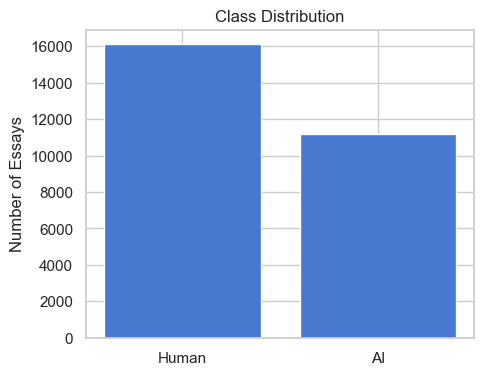


[2] Text length analysis

Word Count stats:
             mean  median  min   max    std
label_name                                 
AI          306.7   319.0   50   785  121.4
Human       419.4   392.0   48  1650  181.1

Character Count stats:
              mean  median  min   max     std
label_name                                   
AI          1937.7  1998.0  263  5064   821.9
Human       2328.3  2173.0  238  9151  1021.8


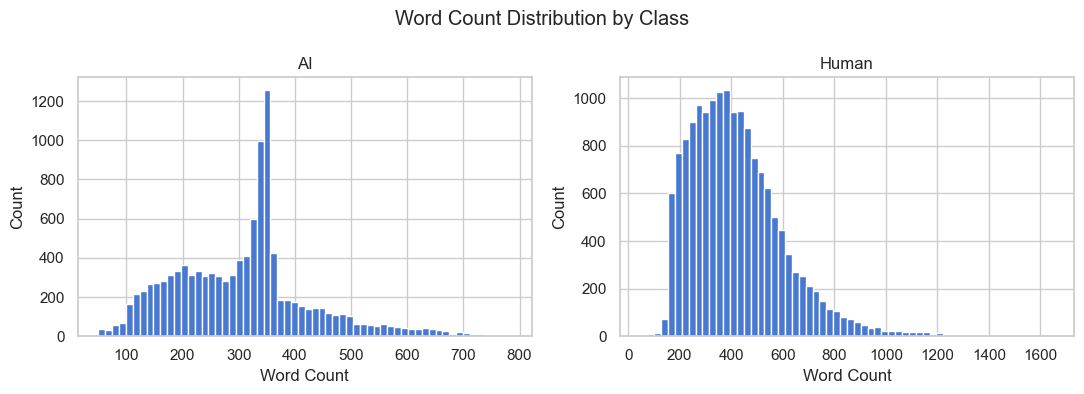

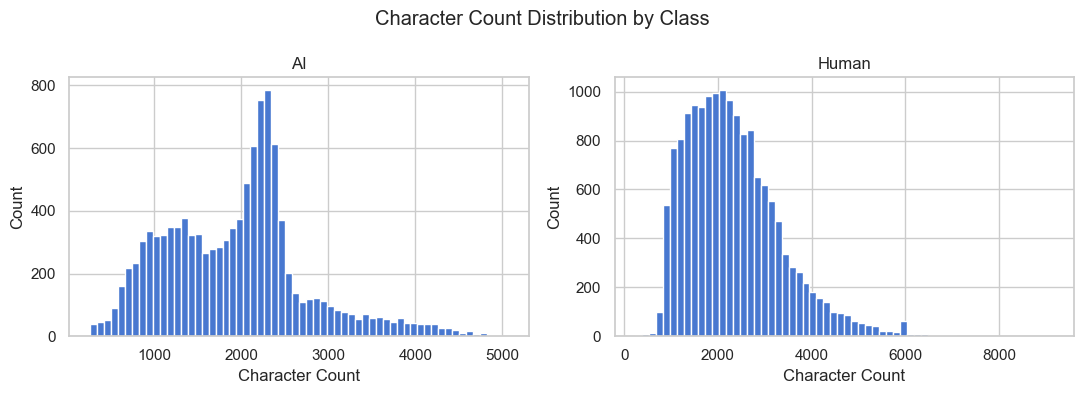

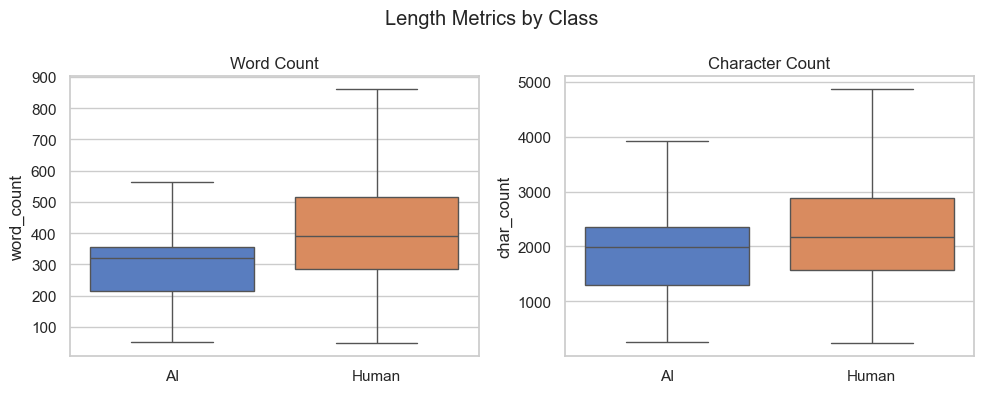


[3] Vocabulary metrics

Type-Token Ratio stats:
             mean  median    min    max    std
label_name                                    
AI          0.582   0.572  0.233  0.877  0.131
Human       0.483   0.486  0.095  0.769  0.088

Avg Word Length (chars) stats:
             mean  median    min    max    std
label_name                                    
AI          5.252   5.297  3.577  6.869  0.473
Human       4.543   4.542  3.426  6.153  0.310

Avg Sentence Length (words) stats:
              mean  median    min      max     std
label_name                                        
AI          20.831  19.718  3.365   51.714   5.605
Human       20.545  18.462  6.133  504.000  12.449


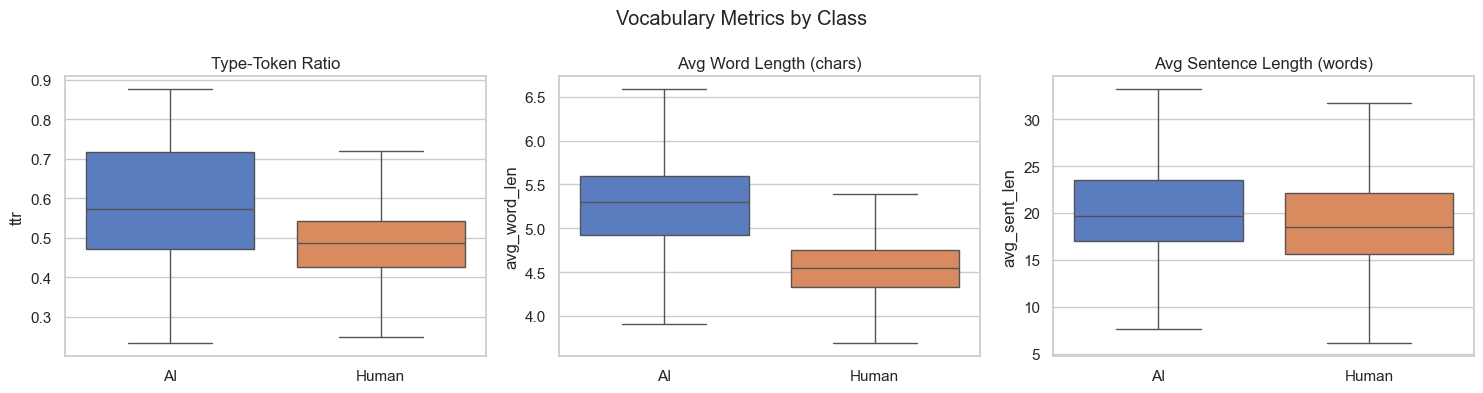

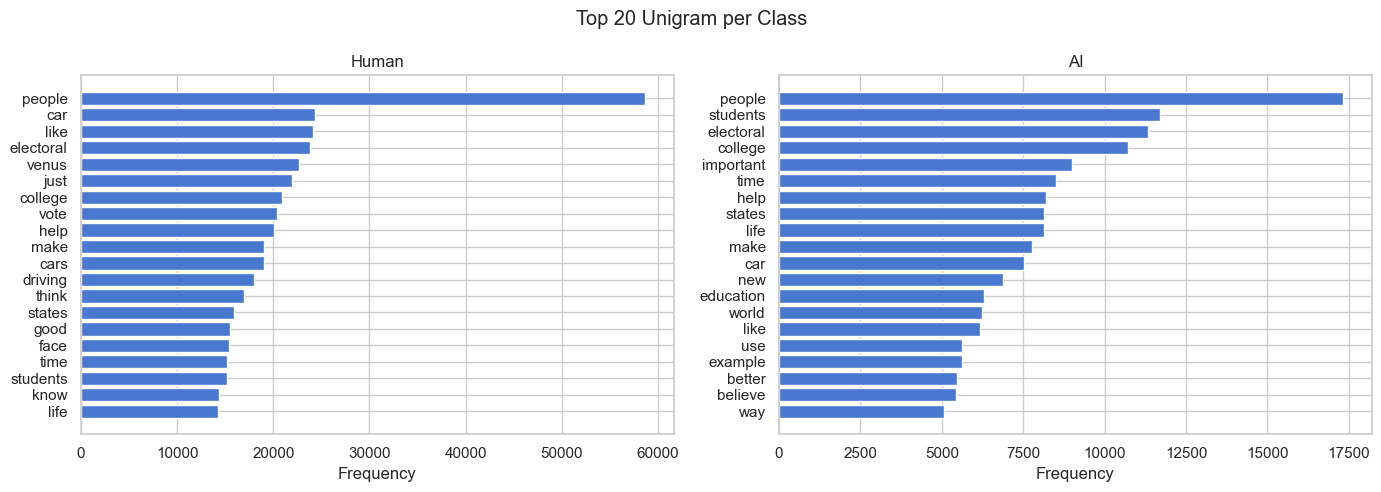

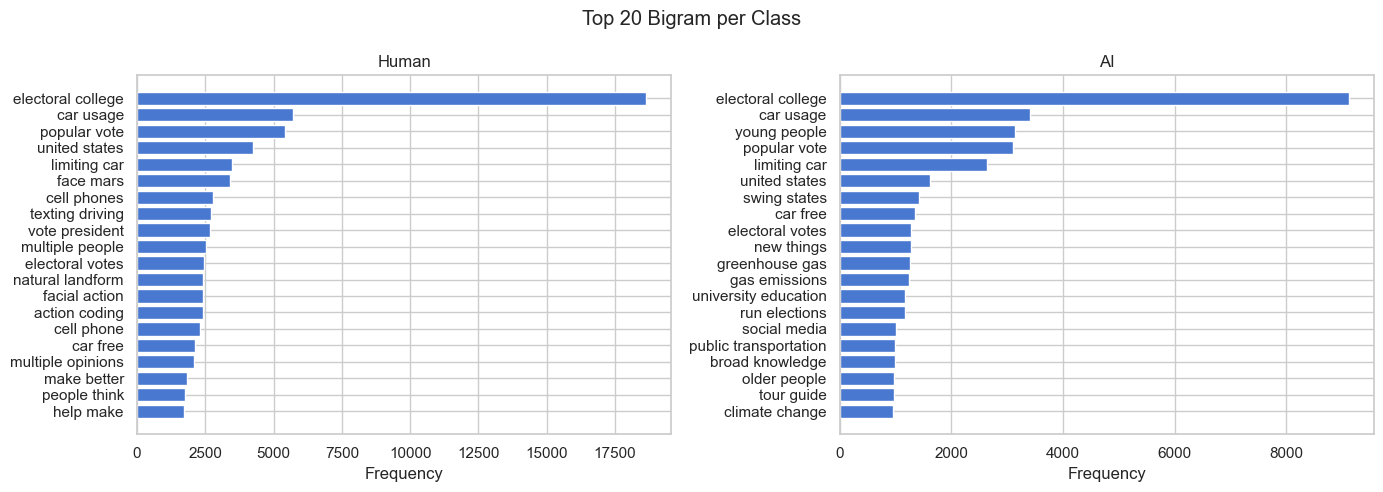


[5] Punctuation and formatting

Punctuation per 1000 chars stats:
             mean  median    std
label_name                      
AI          1.833   1.789  0.551
Human       2.028   1.979  0.681

Paragraph Count stats:
            mean  median  std
label_name                   
AI           1.0     1.0  0.0
Human        1.0     1.0  0.0


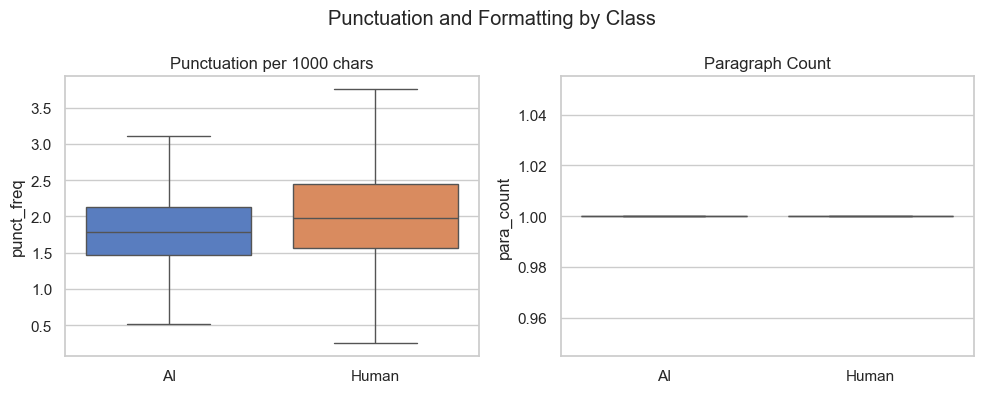

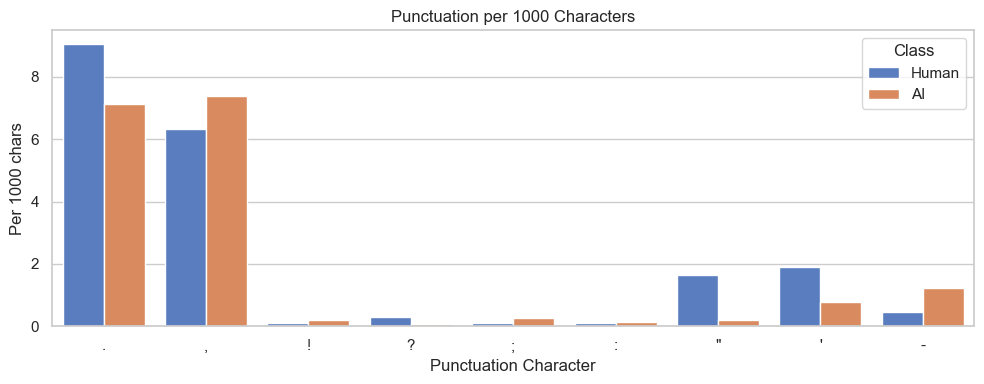

In [12]:
df=cleanData()
df=runAnalysis(df)
plotClassDist(df, 'kaggle_class_distribution')
plotLengthAnalysis(df, 'kaggle_length_analysis')
plotVocabMetrics(df, "kaggle_vocab_metrics")
plotTopTermsUnigram(df, 'kaggle_unigram')
plotTopTermsBigram(df, 'kaggle_bigram')
plotFormatting(df, 'kaggle_formatting')

##TF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
x_train, x_val, x_test, y_train, y_val, y_test=getSplits()

Removed 1861 duplicate essays.
Dataset size after cleaning: 27,278 essays
Label distribution:
label
0    16098
1    11180

Data Sample:                                                 text  label label_name
0  Car-free cities have become a subject of incre...      1         AI
1  Car Free Cities Car-free cities, a concept gai...      1         AI
2  A Sustainable Urban Future Car-free cities are...      1         AI
3  Pioneering Sustainable Urban Living In an era ...      1         AI
4  The Path to Sustainable Urban Living In an age...      1         AI
Split sizes — train: 21,822  val: 2,728  test: 2,728


In [14]:
tfidf=TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True, min_df=5, max_df=0.95, strip_accents="unicode", analyzer="word")

In [15]:
xTrainTFIDF=tfidf.fit_transform(x_train)
xValTFIDF=tfidf.transform(x_val)
xTestTFIDF=tfidf.transform(x_test)

In [16]:
print(f"Vocabulary size : {len(tfidf.vocabulary_):,}")
print(f"Train Shape: {xTrainTFIDF.shape}")
print(f"Val Shape: {xValTFIDF.shape}")
print(f"Test Shape: {xTestTFIDF.shape}")

print("\nTop 20 terms by idf weight:")
terms = tfidf.get_feature_names_out()
idfs  = tfidf.idf_
top20 = np.argsort(idfs)[:20]
for idx in top20:
    print(f"  {terms[idx]:<25} idf={idfs[idx]:.4f}")

Vocabulary size : 50,000
Train Shape: (21822, 50000)
Val Shape: (2728, 50000)
Test Shape: (2728, 50000)

Top 20 terms by idf weight:
  it                        idf=1.0708
  for                       idf=1.0864
  be                        idf=1.1300
  are                       idf=1.1414
  on                        idf=1.1892
  have                      idf=1.1981
  can                       idf=1.2108
  this                      idf=1.2477
  with                      idf=1.2542
  not                       idf=1.2561
  they                      idf=1.2836
  or                        idf=1.2975
  more                      idf=1.3531
  as                        idf=1.3611
  people                    idf=1.3940
  by                        idf=1.4366
  their                     idf=1.4417
  but                       idf=1.4504
  also                      idf=1.4637
  in the                    idf=1.4771


###Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
log_reg=LogisticRegression(C=1, solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=SEED, n_jobs=-1)
log_reg.fit(xTrainTFIDF, y_train)

c:\Users\jgsou\OneDrive\Desktop\Georgia Tech\Courses\CS 7643\DeepLearningProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

###SVM

In [19]:
from sklearn.svm import LinearSVC

In [20]:
svc=LinearSVC(C=1.0,max_iter=2000,class_weight="balanced", random_state=SEED)
svc.fit(xTrainTFIDF, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

###Metrics
- Accuracy
- Recall
- Precision
- F1-Score
- Confusion Matrix

In [21]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve, ConfusionMatrixDisplay, RocCurveDisplay

In [22]:
def genMetrics(y_test, pred, y_proba, save_path):
  print(f"Accuracy= {accuracy_score(y_test, pred)*100:.2f}%")
  print(classification_report(y_test, pred))

  disp = ConfusionMatrixDisplay.from_predictions(y_test, pred,display_labels=["Human", "AI"],cmap="Blues")
  disp.ax_.grid(False)
  plt.title("Confusion Matrix")
  plt.tight_layout()
  plt.show()
  save(disp.figure_, f"confusion_matrix", dir=save_path)

  y_score = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
  disp = RocCurveDisplay.from_predictions(y_test, y_score)
  disp.ax_.grid(False)
  plt.title("ROC Curve")
  plt.tight_layout()
  plt.show()
  save(disp.figure_, f"roc_auc_plot", dir=save_path)

####Kaggle Dataset Test

#### Logistic Regression

Tested on the kaggle dataset: https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset

In [23]:
preds=log_reg.predict(xTestTFIDF)
probs=log_reg.predict_proba(xTestTFIDF)

Accuracy= 99.12%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1610
           1       1.00      0.98      0.99      1118

    accuracy                           0.99      2728
   macro avg       0.99      0.99      0.99      2728
weighted avg       0.99      0.99      0.99      2728



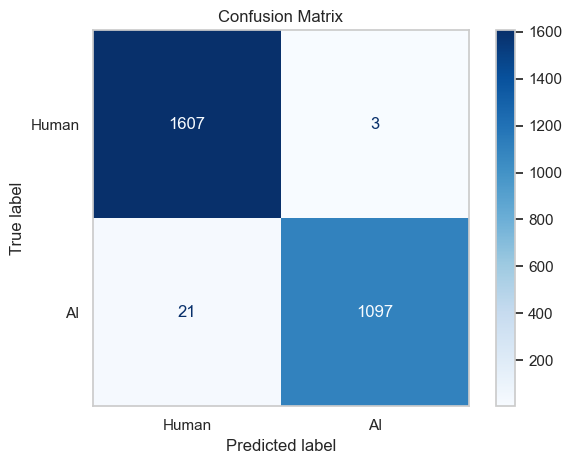

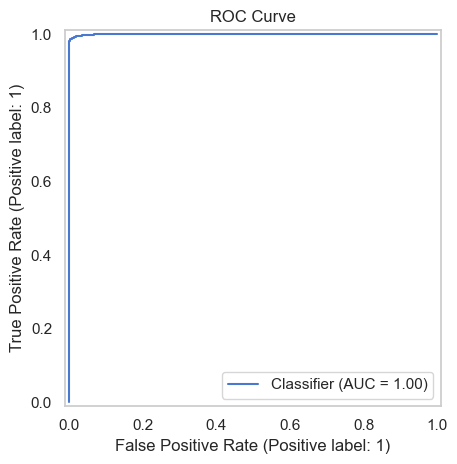

In [24]:
genMetrics(y_test, preds, probs, "results/log_reg")

#### SVM

Tested on the kaggle dataset: https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset

In [25]:
preds=svc.predict(xTestTFIDF)
probs=svc.decision_function(xTestTFIDF)

Accuracy= 99.74%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1610
           1       1.00      0.99      1.00      1118

    accuracy                           1.00      2728
   macro avg       1.00      1.00      1.00      2728
weighted avg       1.00      1.00      1.00      2728



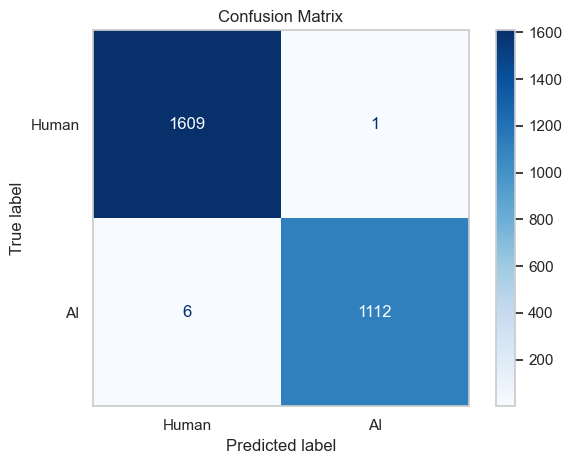

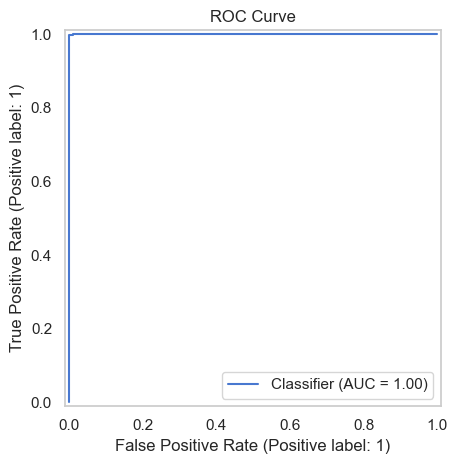

In [26]:
genMetrics(y_test, preds, probs, "results/SVM")


### RAID Testing

In [27]:
from datasets import load_dataset
import itertools

In [28]:
raid=load_dataset("liamdugan/raid", split="train", streaming=True)
samples = list(itertools.islice(raid, 120000))

raid_df=pd.DataFrame.from_dict(samples)[['model','generation']]
raid_df['model']=raid_df['model'].apply(lambda x: 0 if x=='human' else 1)

Removed 34231 duplicate essays.
Dataset size after cleaning: 85,507 essays
Label distribution:
label
1    78628
0     6879

Data Sample:    label                                               text label_name
0      0  The recent advancements in artificial intellig...      Human
1      0  High-quality training data play a key role in ...      Human
2      0  The success of deep learning methods in medica...      Human
3      0  Simultaneous segmentation of multiple organs f...      Human
4      0  Detection faults in seismic data is a crucial ...      Human

[1] Class distribution
       Count  Percentage
label                   
Human   5900        59.0
AI      4100        41.0


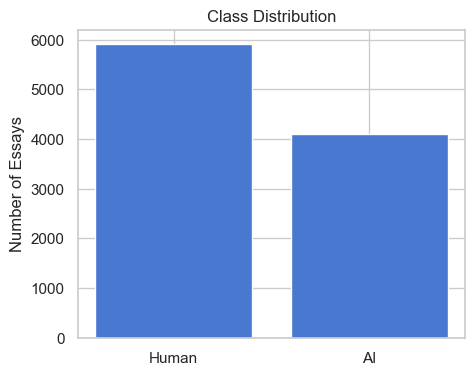


[2] Text length analysis

Word Count stats:
             mean  median  min  max    std
label_name                                
AI          228.5   220.0    2  456  114.0
Human       175.9   172.0   62  312   41.6

Character Count stats:
              mean  median  min   max    std
label_name                                  
AI          1540.4  1538.5   57  3592  729.2
Human       1202.7  1180.0  422  1956  289.8


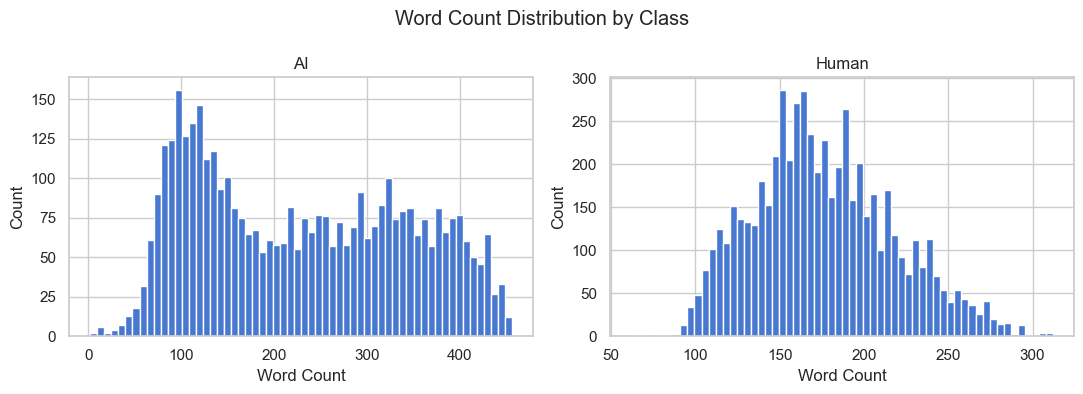

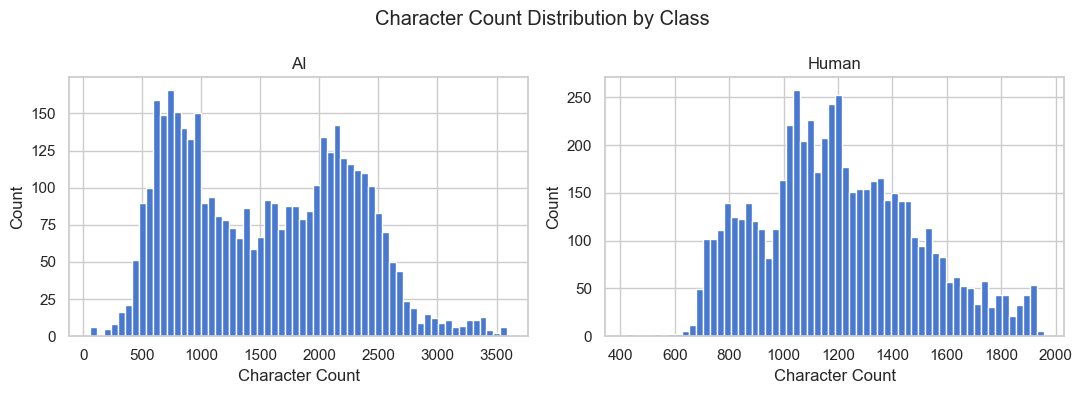

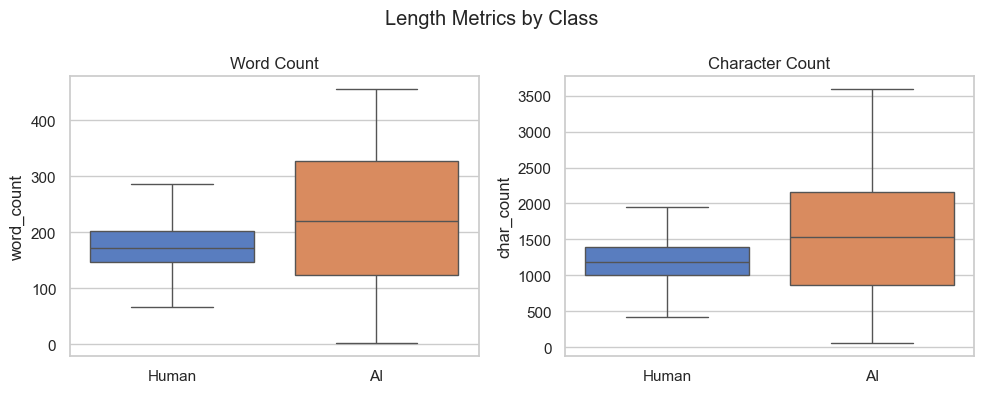


[3] Vocabulary metrics

Type-Token Ratio stats:
             mean  median    min    max    std
label_name                                    
AI          0.612   0.671  0.020  1.000  0.273
Human       0.647   0.648  0.417  0.846  0.059

Avg Word Length (chars) stats:
             mean  median    min      max    std
label_name                                      
AI          6.010   5.892  2.818  293.000  5.153
Human       5.847   5.845  3.782    7.922  0.423

Avg Sentence Length (words) stats:
              mean  median    min    max     std
label_name                                      
AI          26.367  20.667  1.000  429.0  29.060
Human       19.596  19.143  5.167   44.8   4.333


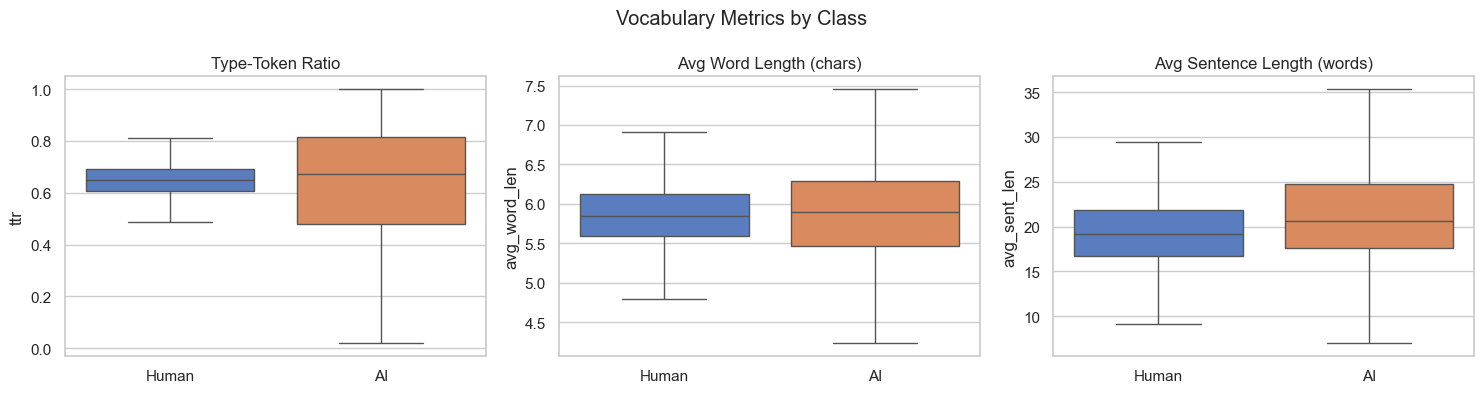

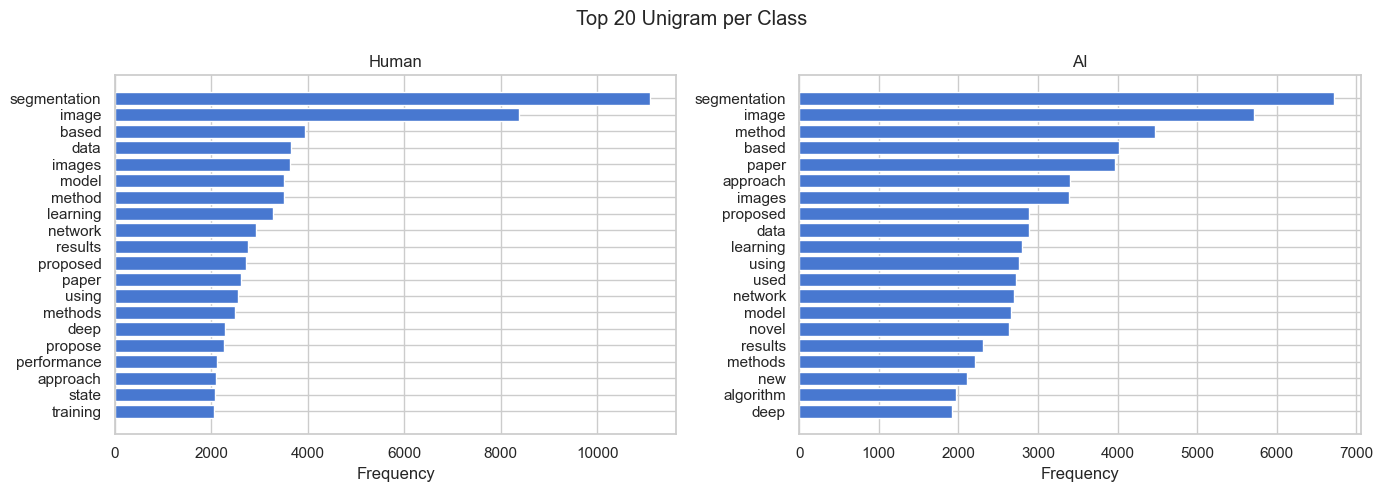

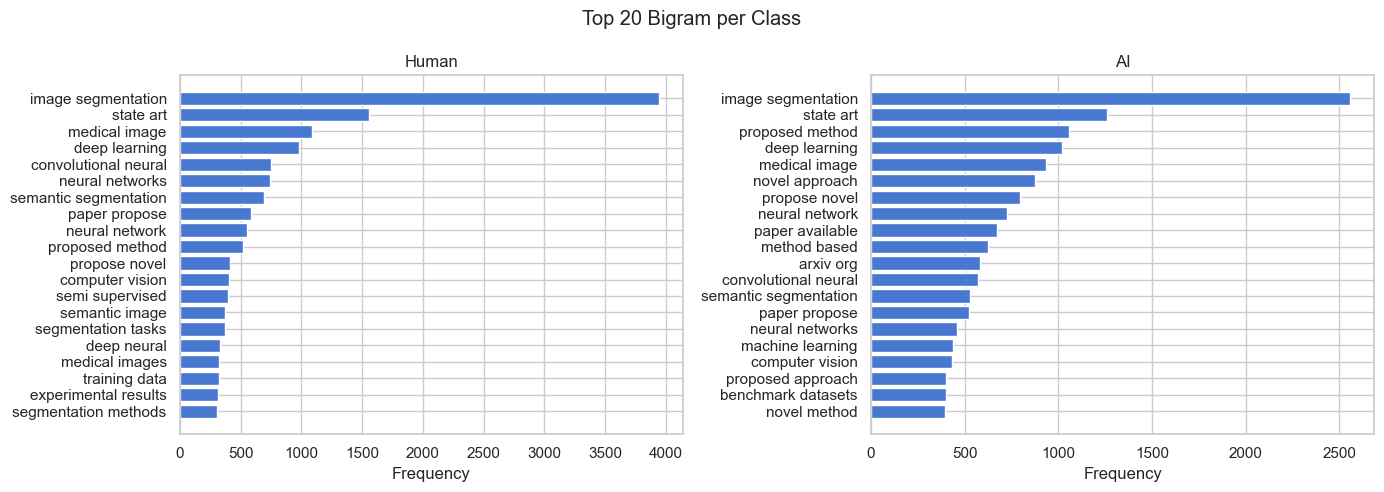


[5] Punctuation and formatting

Punctuation per 1000 chars stats:
             mean  median    std
label_name                      
AI          2.224   1.804  2.359
Human       2.855   2.291  2.177

Paragraph Count stats:
            mean  median  std
label_name                   
AI           1.0     1.0  0.0
Human        1.0     1.0  0.0


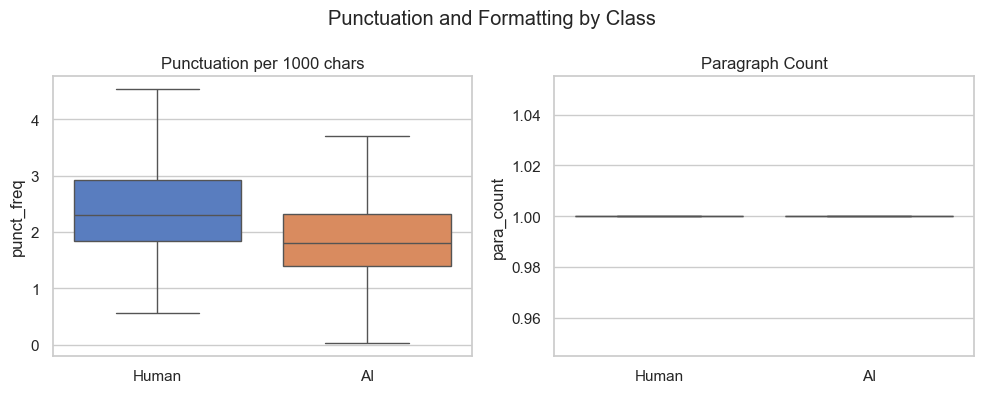

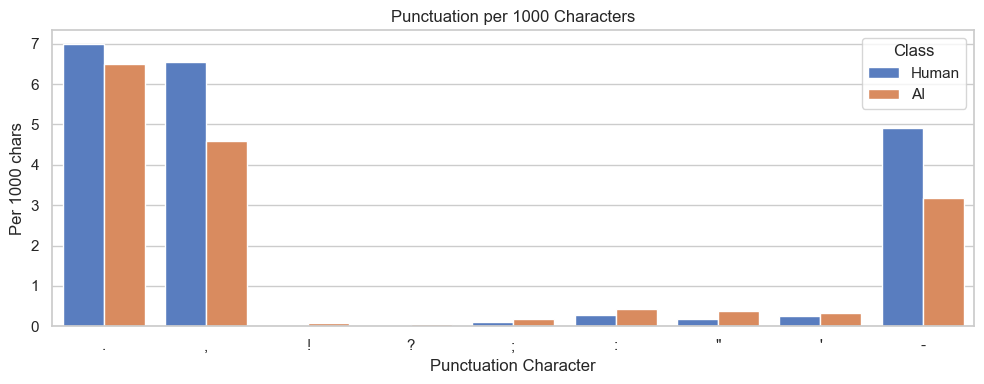

In [29]:
save_path="results/eda_raid"

df=cleanData(df=raid_df, path=None, text_col_name="generation", label_col_name="model")
raid_df=balanceClasses(df, class_weight={0:0.59, 1:0.41}, total_samples=10000)
df=runAnalysis(raid_df)
plotClassDist(df,      'raid_class_distribution', save_path=save_path)
plotLengthAnalysis(df, 'raid_length_analysis'   , save_path=save_path)
plotVocabMetrics(df,   "raid_vocab_metrics"     , save_path=save_path)
plotTopTermsUnigram(df,'raid_unigram'           , save_path=save_path)
plotTopTermsBigram(df, 'raid_bigram'            , save_path=save_path)
plotFormatting(df,     'raid_formatting'        , save_path=save_path)

In [30]:
x_test_raid=raid_df["text"].tolist()
y_test_raid=raid_df["label"].tolist()

raidTFIDF=tfidf.transform(x_test_raid)

#### Logistic Regression

Tested on RAID dataset: https://huggingface.co/datasets/liamdugan/raid

In [31]:
preds=log_reg.predict(raidTFIDF)
probs=log_reg.predict_proba(raidTFIDF)

Accuracy= 40.86%
              precision    recall  f1-score   support

           0       0.06      0.00      0.00      5900
           1       0.41      1.00      0.58      4100

    accuracy                           0.41     10000
   macro avg       0.24      0.50      0.29     10000
weighted avg       0.20      0.41      0.24     10000



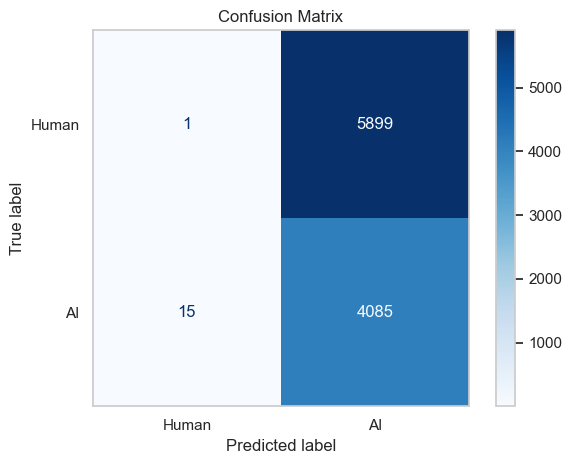

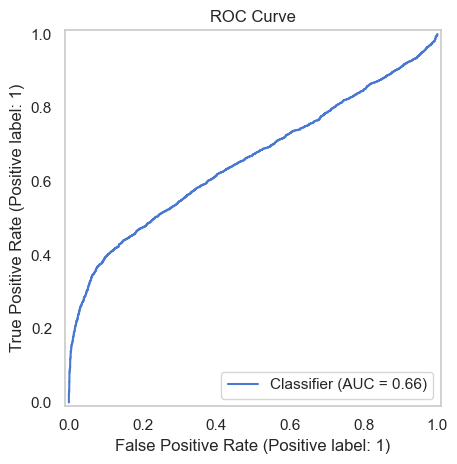

In [32]:
genMetrics(y_test_raid, preds, probs, "results/raid_log_reg")

#### SVM

Tested on RAID dataset: https://huggingface.co/datasets/liamdugan/raid

In [33]:
preds=svc.predict(raidTFIDF)
probs=svc.decision_function(raidTFIDF)

Accuracy= 40.90%
              precision    recall  f1-score   support

           0       0.34      0.00      0.00      5900
           1       0.41      0.99      0.58      4100

    accuracy                           0.41     10000
   macro avg       0.38      0.50      0.29     10000
weighted avg       0.37      0.41      0.24     10000



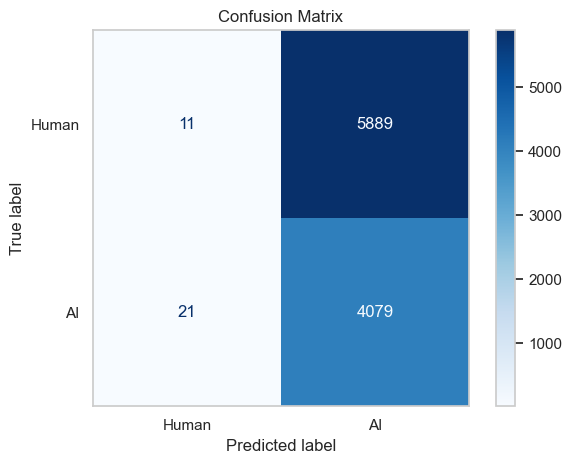

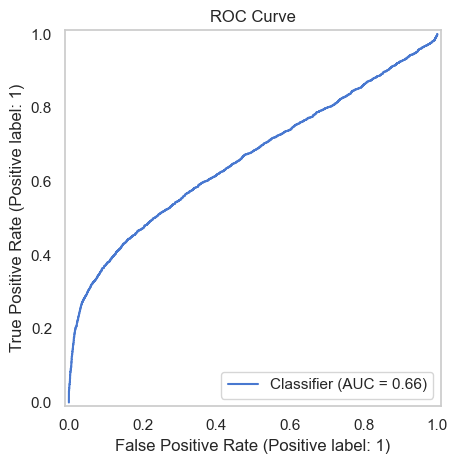

In [34]:
genMetrics(y_test_raid, preds, probs, "results/raid_SVM")


## Likelihood Baseline: GLTR-Style Heuristic Features

This second baseline mirrors the TF-IDF workflow, but replaces sparse n-gram features with essay-level likelihood statistics from a small causal language model. Inspired by GLTR-style detection, we summarize how predictable each essay is under the reference LM using token-rank and surprisal features, then train the same downstream classifiers.


In [35]:
import math
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.preprocessing import StandardScaler


In [36]:
LIKELIHOOD_MODEL_NAME = 'distilgpt2'
MAX_LM_TOKENS = 512
LM_BATCH_SIZE = 8
TOP_K_BUCKETS = (10, 100, 1000)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Likelihood model: {LIKELIHOOD_MODEL_NAME}')
print(f'Device: {DEVICE}')


Likelihood model: distilgpt2
Device: cuda


In [37]:
def loadLikelihoodModel(model_name=LIKELIHOOD_MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_name)
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


def _safe_stat(values, fn, default=0.0):
    if len(values) == 0:
        return float(default)
    return float(fn(values))


def _top_k_share(ranks, k):
    if len(ranks) == 0:
        return 0.0
    ranks = np.asarray(ranks)
    return float(np.mean(ranks <= k))


def summarizeLikelihoodStats(token_log_probs, token_ranks, token_entropies, token_count, char_count):
    token_log_probs = np.asarray(token_log_probs, dtype=np.float32)
    token_ranks = np.asarray(token_ranks, dtype=np.float32)
    token_entropies = np.asarray(token_entropies, dtype=np.float32)

    surprisals = -token_log_probs if token_log_probs.size else np.asarray([], dtype=np.float32)

    stats = {
        'token_count_lm': float(token_count),
        'char_count': float(char_count),
        'chars_per_token': float(char_count / max(token_count, 1)),
        'mean_log_prob': _safe_stat(token_log_probs, np.mean),
        'std_log_prob': _safe_stat(token_log_probs, np.std),
        'mean_surprisal': _safe_stat(surprisals, np.mean),
        'std_surprisal': _safe_stat(surprisals, np.std),
        'mean_rank': _safe_stat(token_ranks, np.mean),
        'median_rank': _safe_stat(token_ranks, np.median),
        'max_rank': _safe_stat(token_ranks, np.max),
        'rank_std': _safe_stat(token_ranks, np.std),
        'mean_entropy': _safe_stat(token_entropies, np.mean),
        'std_entropy': _safe_stat(token_entropies, np.std),
    }

    for k in TOP_K_BUCKETS:
        stats[f'share_top_{k}'] = _top_k_share(token_ranks, k)

    return stats


def extractLikelihoodFeatures(texts, tokenizer, model, batch_size=LM_BATCH_SIZE, max_length=MAX_LM_TOKENS):
    features = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            logits = outputs.logits[:, :-1, :]

        input_ids = encoded['input_ids'][:, 1:]
        attention_mask = encoded['attention_mask'][:, 1:].bool()
        log_probs = torch.log_softmax(logits, dim=-1)
        probs = torch.softmax(logits, dim=-1)
        entropies = -(probs * log_probs).sum(dim=-1)
        target_log_probs = log_probs.gather(-1, input_ids.unsqueeze(-1)).squeeze(-1)
        greater_counts = (logits > logits.gather(-1, input_ids.unsqueeze(-1))).sum(dim=-1)
        target_ranks = greater_counts + 1

        for row_idx, text in enumerate(batch):
            valid = attention_mask[row_idx]
            token_log_probs = target_log_probs[row_idx][valid].detach().cpu().numpy()
            token_ranks = target_ranks[row_idx][valid].detach().cpu().numpy()
            token_entropies = entropies[row_idx][valid].detach().cpu().numpy()
            token_count = int(valid.sum().item())
            features.append(
                summarizeLikelihoodStats(
                    token_log_probs=token_log_probs,
                    token_ranks=token_ranks,
                    token_entropies=token_entropies,
                    token_count=token_count,
                    char_count=len(text),
                )
            )

    return pd.DataFrame(features)


In [38]:
likelihood_tokenizer, likelihood_model = loadLikelihoodModel()
x_train, x_val, x_test, y_train, y_val, y_test = getSplits()

xTrainLikelihood = extractLikelihoodFeatures(x_train, likelihood_tokenizer, likelihood_model)
xValLikelihood = extractLikelihoodFeatures(x_val, likelihood_tokenizer, likelihood_model)
xTestLikelihood = extractLikelihoodFeatures(x_test, likelihood_tokenizer, likelihood_model)

likelihood_features = xTrainLikelihood.columns.tolist()
likelihood_scaler = StandardScaler()
xTrainLikelihoodScaled = likelihood_scaler.fit_transform(xTrainLikelihood)
xValLikelihoodScaled = likelihood_scaler.transform(xValLikelihood)
xTestLikelihoodScaled = likelihood_scaler.transform(xTestLikelihood)

print(f'Likelihood feature count: {len(likelihood_features)}')
print(likelihood_features)
print(f'Train Shape: {xTrainLikelihoodScaled.shape}')
print(f'Val Shape: {xValLikelihoodScaled.shape}')
print(f'Test Shape: {xTestLikelihoodScaled.shape}')
xTrainLikelihood.head()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Removed 1861 duplicate essays.
Dataset size after cleaning: 27,278 essays
Label distribution:
label
0    16098
1    11180

Data Sample:                                                 text  label label_name
0  Car-free cities have become a subject of incre...      1         AI
1  Car Free Cities Car-free cities, a concept gai...      1         AI
2  A Sustainable Urban Future Car-free cities are...      1         AI
3  Pioneering Sustainable Urban Living In an era ...      1         AI
4  The Path to Sustainable Urban Living In an age...      1         AI
Split sizes — train: 21,822  val: 2,728  test: 2,728
Likelihood feature count: 16
['token_count_lm', 'char_count', 'chars_per_token', 'mean_log_prob', 'std_log_prob', 'mean_surprisal', 'std_surprisal', 'mean_rank', 'median_rank', 'max_rank', 'rank_std', 'mean_entropy', 'std_entropy', 'share_top_10', 'share_top_100', 'share_top_1000']
Train Shape: (21822, 16)
Val Shape: (2728, 16)
Test Shape: (2728, 16)


,token_count_lm,char_count,chars_per_token,mean_log_prob,std_log_prob,mean_surprisal,std_surprisal,mean_rank,median_rank,max_rank,rank_std,mean_entropy,std_entropy,share_top_10,share_top_100,share_top_1000
0,511.0,3075.0,6.017613,-2.592824,2.268766,2.592824,2.268766,23.739725,2.0,2260.0,140.380600,2.897235,1.609368,0.784736,0.953033,0.996086
1,206.0,973.0,4.723301,-4.577978,3.183533,4.577978,3.183533,335.679626,8.5,9360.0,1223.459717,4.145263,1.724839,0.514563,0.771845,0.932039
2,387.0,2511.0,6.488372,-3.760087,3.028538,3.760087,3.028538,87.886307,5.0,6825.0,505.757690,2.880191,1.628144,0.612403,0.899225,0.981912
3,205.0,955.0,4.658537,-4.425486,3.038538,4.425486,3.038538,251.804871,8.0,9072.0,1089.158691,4.006917,1.453701,0.565854,0.839024,0.956098
4,511.0,2691.0,5.266145,-4.052761,3.184888,4.052761,3.184888,244.156555,4.0,25203.0,1360.605103,3.701582,1.533751,0.614481,0.823875,0.947162


### Logistic Regression


In [39]:
likelihood_log_reg = LogisticRegression(C=1, solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=SEED)
likelihood_log_reg.fit(xTrainLikelihoodScaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

#### Kaggle Dataset Test

Tested on the kaggle dataset: https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset


In [40]:
preds = likelihood_log_reg.predict(xTestLikelihoodScaled)
probs = likelihood_log_reg.predict_proba(xTestLikelihoodScaled)


Accuracy= 95.42%
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1610
           1       0.93      0.96      0.94      1118

    accuracy                           0.95      2728
   macro avg       0.95      0.95      0.95      2728
weighted avg       0.95      0.95      0.95      2728



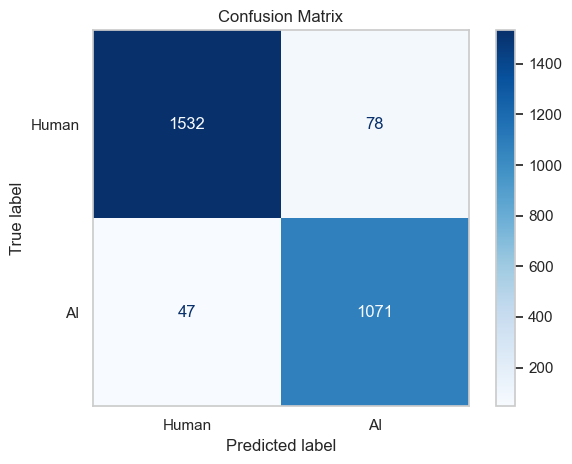

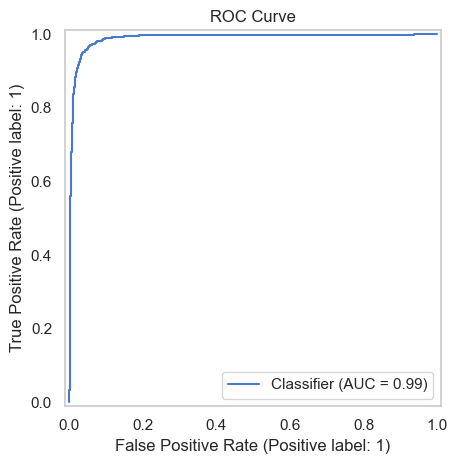

In [41]:
genMetrics(y_test, preds, probs, 'results/gltr_log_reg')


### SVM


In [42]:
likelihood_svc = LinearSVC(C=1.0, max_iter=4000, class_weight='balanced', random_state=SEED)
likelihood_svc.fit(xTrainLikelihoodScaled, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

#### Kaggle Dataset Test

Tested on the kaggle dataset: https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset


In [43]:
preds = likelihood_svc.predict(xTestLikelihoodScaled)
probs = likelihood_svc.decision_function(xTestLikelihoodScaled)


Accuracy= 95.64%
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1610
           1       0.94      0.96      0.95      1118

    accuracy                           0.96      2728
   macro avg       0.95      0.96      0.96      2728
weighted avg       0.96      0.96      0.96      2728



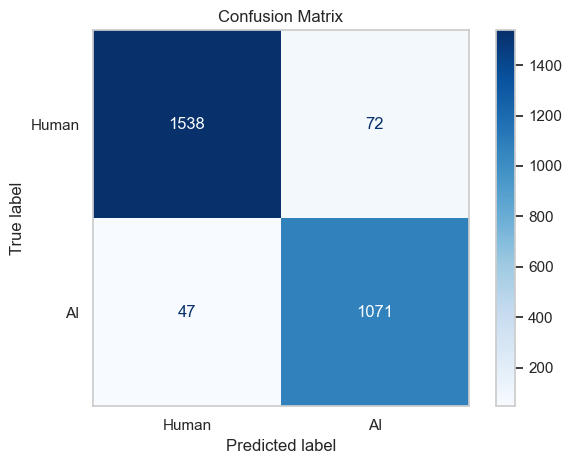

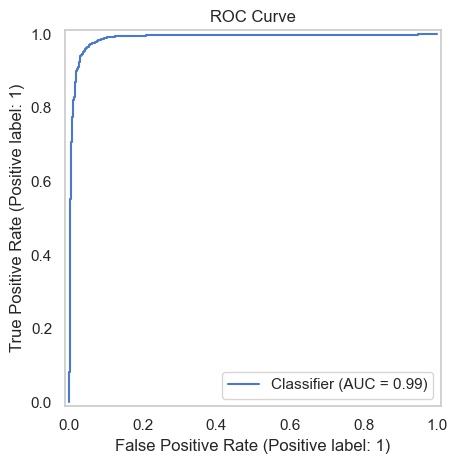

In [44]:
genMetrics(y_test, preds, probs, 'results/gltr_SVM')


### RAID Testing


In [45]:
raid = load_dataset('liamdugan/raid', split='train', streaming=True)
samples = list(itertools.islice(raid, 120000))
raid_df = pd.DataFrame.from_dict(samples)[['model', 'generation']]
raid_df['model'] = raid_df['model'].apply(lambda x: 0 if x == 'human' else 1)
raid_df = cleanData(df=raid_df, path=None, text_col_name='generation', label_col_name='model')
raid_df = balanceClasses(raid_df, class_weight={0: 0.59, 1: 0.41}, total_samples=10000)
x_test_raid = raid_df['text'].tolist()
y_test_raid = raid_df['label'].tolist()


Removed 34231 duplicate essays.
Dataset size after cleaning: 85,507 essays
Label distribution:
label
1    78628
0     6879

Data Sample:    label                                               text label_name
0      0  The recent advancements in artificial intellig...      Human
1      0  High-quality training data play a key role in ...      Human
2      0  The success of deep learning methods in medica...      Human
3      0  Simultaneous segmentation of multiple organs f...      Human
4      0  Detection faults in seismic data is a crucial ...      Human


In [46]:
xTestRaidLikelihood = extractLikelihoodFeatures(x_test_raid, likelihood_tokenizer, likelihood_model)
xTestRaidLikelihoodScaled = likelihood_scaler.transform(xTestRaidLikelihood)
xTestRaidLikelihood.head()


,token_count_lm,char_count,chars_per_token,mean_log_prob,std_log_prob,mean_surprisal,std_surprisal,mean_rank,median_rank,max_rank,rank_std,mean_entropy,std_entropy,share_top_10,share_top_100,share_top_1000
0,222.0,1121.0,5.049550,-4.013238,3.468598,4.013238,3.468598,362.391907,4.0,15292.0,1657.217163,3.720168,1.878957,0.626126,0.752252,0.936937
1,262.0,1407.0,5.370229,-4.146400,3.364138,4.146400,3.364138,324.064880,5.0,17519.0,1513.074707,3.999810,2.010394,0.576336,0.790076,0.935115
2,310.0,1647.0,5.312903,-4.256326,3.637461,4.256326,3.637461,446.664520,5.0,19157.0,1958.016602,3.648784,1.885764,0.596774,0.787097,0.922581
3,264.0,1457.0,5.518939,-3.991957,3.275888,3.991957,3.275888,206.428024,5.0,6773.0,749.279724,3.831225,1.922813,0.625000,0.829545,0.946970
4,191.0,1044.0,5.465969,-4.153955,3.138947,4.153955,3.138947,188.554977,6.0,8939.0,737.226807,4.021206,2.021502,0.596859,0.774869,0.952880


#### Logistic Regression

Tested on RAID dataset: https://huggingface.co/datasets/liamdugan/raid


In [47]:
preds = likelihood_log_reg.predict(xTestRaidLikelihoodScaled)
probs = likelihood_log_reg.predict_proba(xTestRaidLikelihoodScaled)


Accuracy= 57.78%
              precision    recall  f1-score   support

           0       0.94      0.30      0.46      5900
           1       0.49      0.97      0.65      4100

    accuracy                           0.58     10000
   macro avg       0.72      0.64      0.56     10000
weighted avg       0.76      0.58      0.54     10000



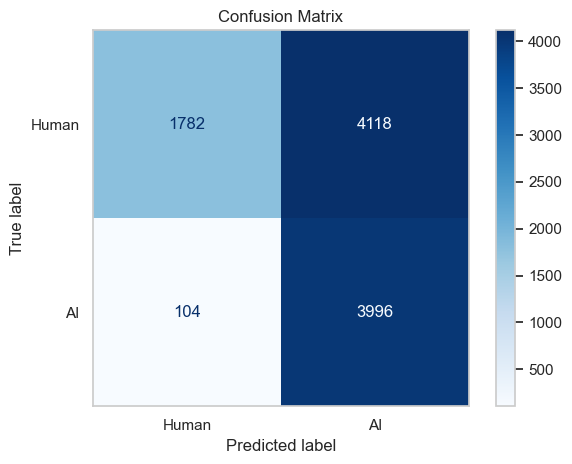

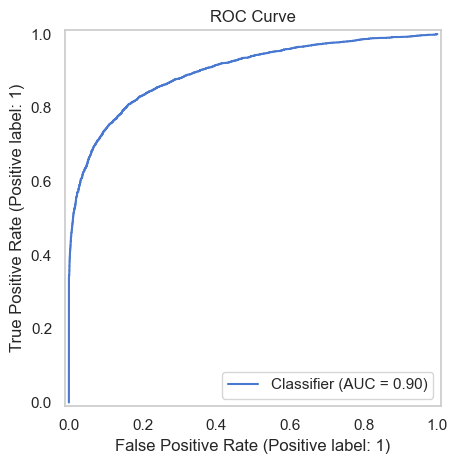

In [48]:
genMetrics(y_test_raid, preds, probs, 'results/raid_gltr_log_reg')


#### SVM

Tested on RAID dataset: https://huggingface.co/datasets/liamdugan/raid


In [49]:
preds = likelihood_svc.predict(xTestRaidLikelihoodScaled)
probs = likelihood_svc.decision_function(xTestRaidLikelihoodScaled)


Accuracy= 55.20%
              precision    recall  f1-score   support

           0       0.94      0.26      0.40      5900
           1       0.48      0.97      0.64      4100

    accuracy                           0.55     10000
   macro avg       0.71      0.62      0.52     10000
weighted avg       0.75      0.55      0.50     10000



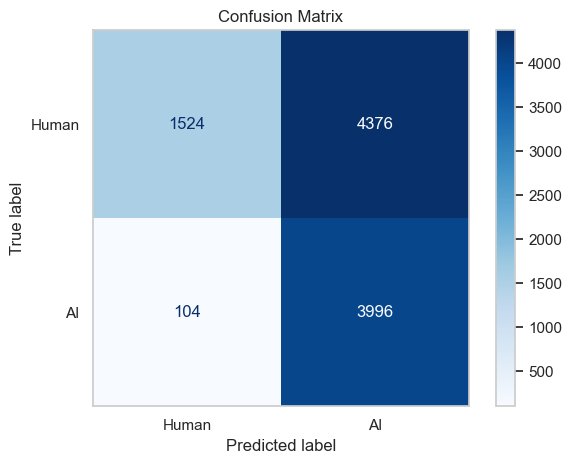

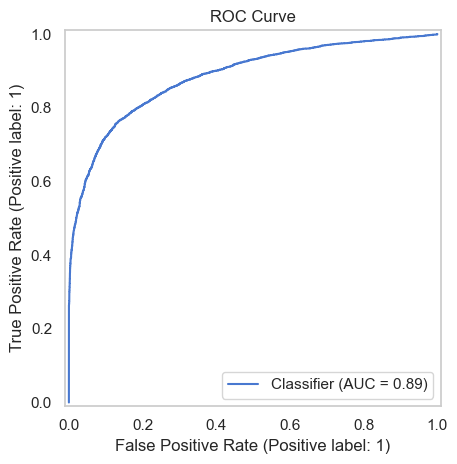

In [50]:
genMetrics(y_test_raid, preds, probs, 'results/raid_gltr_SVM')
